In [2]:
import pandas as pd
import numpy as np

In [3]:
train_df = pd.read_csv("../dataset/raw/UNSW_NB15_training-set.csv")
test_df = pd.read_csv("../dataset/raw/UNSW_NB15_testing-set.csv")

print("Training Shape:", train_df.shape)
print("Testing Shape:", test_df.shape)

Training Shape: (82332, 45)
Testing Shape: (175341, 45)


In [4]:
missing = train_df.isnull().sum()

missing[missing > 0]

Series([], dtype: int64)

In [5]:
train_df.isnull().sum().sum()
train_df.duplicated().sum()
train_df = train_df.drop_duplicates()

test_df = test_df.drop_duplicates()
train_df.duplicated().sum()
print(train_df.shape)
print(test_df.shape)
train_df.info()

(82332, 45)
(175341, 45)
<class 'pandas.DataFrame'>
RangeIndex: 82332 entries, 0 to 82331
Data columns (total 45 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 82332 non-null  int64  
 1   dur                82332 non-null  float64
 2   proto              82332 non-null  str    
 3   service            82332 non-null  str    
 4   state              82332 non-null  str    
 5   spkts              82332 non-null  int64  
 6   dpkts              82332 non-null  int64  
 7   sbytes             82332 non-null  int64  
 8   dbytes             82332 non-null  int64  
 9   rate               82332 non-null  float64
 10  sttl               82332 non-null  int64  
 11  dttl               82332 non-null  int64  
 12  sload              82332 non-null  float64
 13  dload              82332 non-null  float64
 14  sloss              82332 non-null  int64  
 15  dloss              82332 non-null  int64  
 16  sinpkt  

In [6]:
numerical_cols = train_df.select_dtypes(include=['int64','float64']).columns

print(numerical_cols)
categorical_cols = train_df.select_dtypes(include=['object']).columns

print(categorical_cols)


Index(['id', 'dur', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl',
       'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit',
       'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat',
       'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src',
       'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm',
       'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd',
       'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports', 'label'],
      dtype='str')
Index(['proto', 'service', 'state', 'attack_cat'], dtype='str')


C:\Users\Sonakshi\AppData\Local\Temp\ipykernel_16716\3077354818.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = train_df.select_dtypes(include=['object']).columns


In [8]:
for col in categorical_cols:
    print(col)
    print(train_df[col].unique())
    print("-------------------")
    np.isinf(train_df.select_dtypes(include=np.number)).sum().sum()
    train_df.replace([np.inf,-np.inf],np.nan,inplace=True)

proto
<ArrowStringArray>
[     'udp',      'arp',      'tcp',     'igmp',     'ospf',     'sctp',
      'gre',      'ggp',       'ip',    'ipnip',
 ...
     'isis',      'ptp',     'fire',     'crtp',    'crudp', 'sccopmce',
     'iplt',     'pipe',      'sps',       'ib']
Length: 131, dtype: str
-------------------
service
<ArrowStringArray>
[       '-',     'http',      'ftp', 'ftp-data',     'smtp',     'pop3',
      'dns',     'snmp',      'ssl',     'dhcp',      'irc',   'radius',
      'ssh']
Length: 13, dtype: str
-------------------
state
<ArrowStringArray>
['INT', 'FIN', 'REQ', 'ACC', 'CON', 'RST', 'CLO']
Length: 7, dtype: str
-------------------
attack_cat
<ArrowStringArray>
[        'Normal', 'Reconnaissance',       'Backdoor',            'DoS',
       'Exploits',       'Analysis',        'Fuzzers',          'Worms',
      'Shellcode',        'Generic']
Length: 10, dtype: str
-------------------


In [9]:
train_df = train_df.dropna()

test_df = test_df.dropna()
print(train_df.isnull().sum().sum())
print(test_df.isnull().sum().sum())

0
0


Matplotlib is building the font cache; this may take a moment.


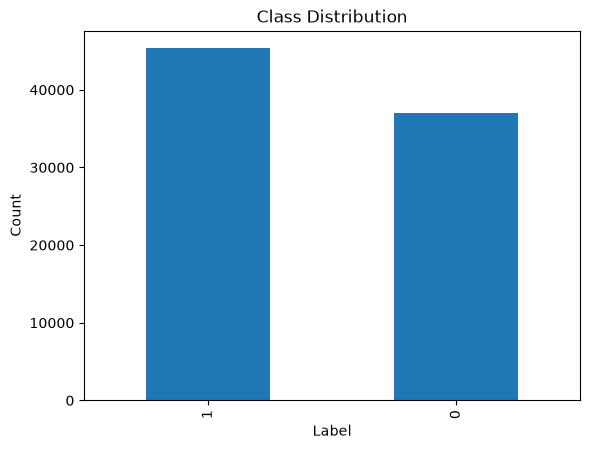

In [10]:
train_df['label'].value_counts()
import matplotlib.pyplot as plt

train_df['label'].value_counts().plot(kind='bar')

plt.title("Class Distribution")

plt.xlabel("Label")

plt.ylabel("Count")

plt.show()

In [11]:
train_df['attack_cat'].value_counts()

attack_cat
Normal            37000
Generic           18871
Exploits          11132
Fuzzers            6062
DoS                4089
Reconnaissance     3496
Analysis            677
Backdoor            583
Shellcode           378
Worms                44
Name: count, dtype: int64

In [12]:
train_df.to_csv("../dataset/processed/train_clean.csv",index=False)

test_df.to_csv("../dataset/processed/test_clean.csv",index=False)

In [13]:
train_clean = pd.read_csv("../dataset/processed/train_clean.csv")

train_clean.head()

,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.000011,udp,-,INT,2,0,496,0,90909.0902,...,1,2,0,0,0,1,2,0,Normal,0
1,2,0.000008,udp,-,INT,2,0,1762,0,125000.0003,...,1,2,0,0,0,1,2,0,Normal,0
2,3,0.000005,udp,-,INT,2,0,1068,0,200000.0051,...,1,3,0,0,0,1,3,0,Normal,0
3,4,0.000006,udp,-,INT,2,0,900,0,166666.6608,...,1,3,0,0,0,2,3,0,Normal,0
4,5,0.000010,udp,-,INT,2,0,2126,0,100000.0025,...,1,3,0,0,0,2,3,0,Normal,0
